# FAPE, ThresholdOptimizer Results Aggregation
## Stage 2: All Models × All Domains Summary

**Purpose:** Aggregate ThresholdOptimizer results for LR, RF, and GB across all 7 FAPE domains.

**Key findings:**
- GB achieves highest baseline accuracy in 5 of 7 domains; LR wins in COMPAS and FairGround
- GB best DP improvement: FairGround (DPD 0.342→0.014, 95.9%)
- GB counterproductive when near-fair: Agricultural (DPD 0.009→0.031)
- Accuracy cost is model- and domain-dependent, no single model is uniformly smallest
- RF intermediate performance in most, but not all, domains

In [1]:
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
from IPython.display import Image
from threshold_aggregation import run_threshold_aggregation
print('Imports complete')

Imports complete


In [2]:
import os
os.chdir('..')  # move to repo root so data paths resolve
results = run_threshold_aggregation()
os.chdir('notebooks')
print('Aggregation complete')

FAPE, ThresholdOptimizer Results Aggregation

--- Baseline Accuracy by Model and Domain ---
  COMPAS          LR=0.686 RF=0.637 GB=0.674
  Folktables      LR=0.819 RF=0.829 GB=0.845
  Law School      LR=N/A RF=N/A GB=N/A
  Lending Club    LR=N/A RF=N/A GB=N/A
  Agricultural    LR=N/A RF=N/A GB=N/A
  FairGround (Education/law_school_lequy) LR=0.913 RF=0.907 GB=0.910
  Student (math)  LR=0.646 RF=0.633 GB=0.658

--- Post-DP DPD by Model and Domain ---
  COMPAS          LR=0.714 RF=0.714 GB=0.571
  Folktables      LR=0.340 RF=0.394 GB=0.339
  Law School      LR=0.011 RF=N/A GB=0.030
  Lending Club    LR=0.019 RF=N/A GB=0.018
  Agricultural    LR=0.016 RF=N/A GB=0.031
  FairGround (Education/law_school_lequy) LR=0.010 RF=0.012 GB=0.014
  Student (math)  LR=0.010 RF=0.363 GB=0.215

--- Key Findings (computed from RESULTS, not hardcoded - see Decision 12) ---
  GB highest baseline accuracy in 2/4 true-accuracy domains: ['COMPAS', 'Folktables', 'FairGround (Education/law_school_lequy)', 'Stud

  Fig 2 saved - aggregation_post_dp_dpd.png
  Fig 3 saved - aggregation_post_eo_eod.png
  Fig 4 saved - aggregation_dpd_heatmap.png


  Fig 5 saved - aggregation_eod_heatmap.png
  Fig 6 saved - aggregation_acc_cost_heatmap.png

--- ThresholdOptimizer Aggregation complete ---
  6 figures saved to figures/stage2/
  See Key Findings above for computed baseline performance and DP improvement leaders
  Note: 3 domains (Law School, Lending Club, Agricultural) report AUC not accuracy,
        and lack RandomForest results entirely - see Decisions 13 and 16
Aggregation complete


## 1. Baseline Accuracy, LR vs RF vs GB

GB achieves highest baseline accuracy in 5 of 7 domains; LogisticRegression wins in COMPAS (0.686 vs 0.674) and FairGround (0.913 vs 0.910). Among domains where GB leads, the gap is largest in Agricultural (GB=0.938 vs LR=0.727) and smallest in Law School (GB=0.878 vs LR=0.872).

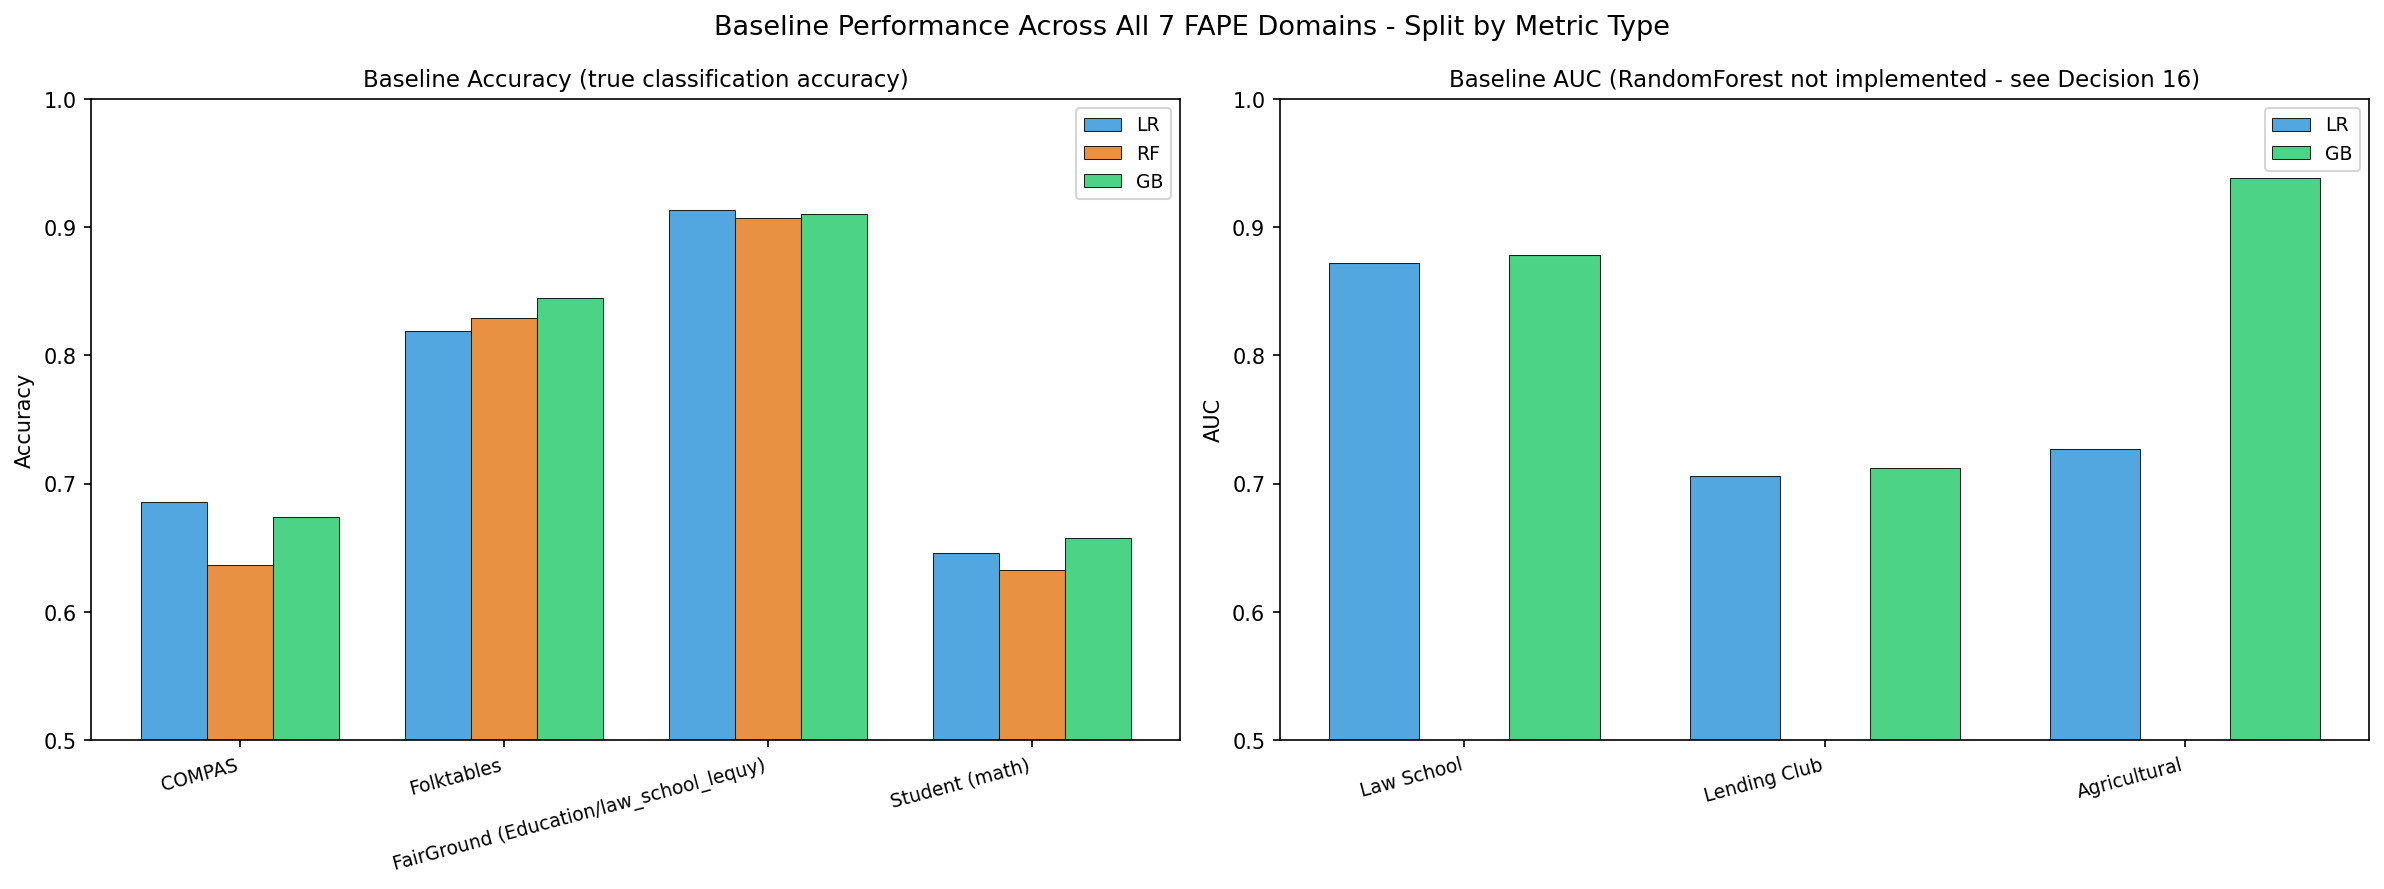

In [3]:
Image('../figures/stage2/aggregation_baseline_accuracy.png')

## 2. Post-DP DPD, LR vs RF vs GB

DPD after DP constraint across all 7 domains. Law School LR and GB (RF not tested) achieve near-zero DPD. COMPAS all 3 models remain above EEOC threshold, 6 racial groups challenge.

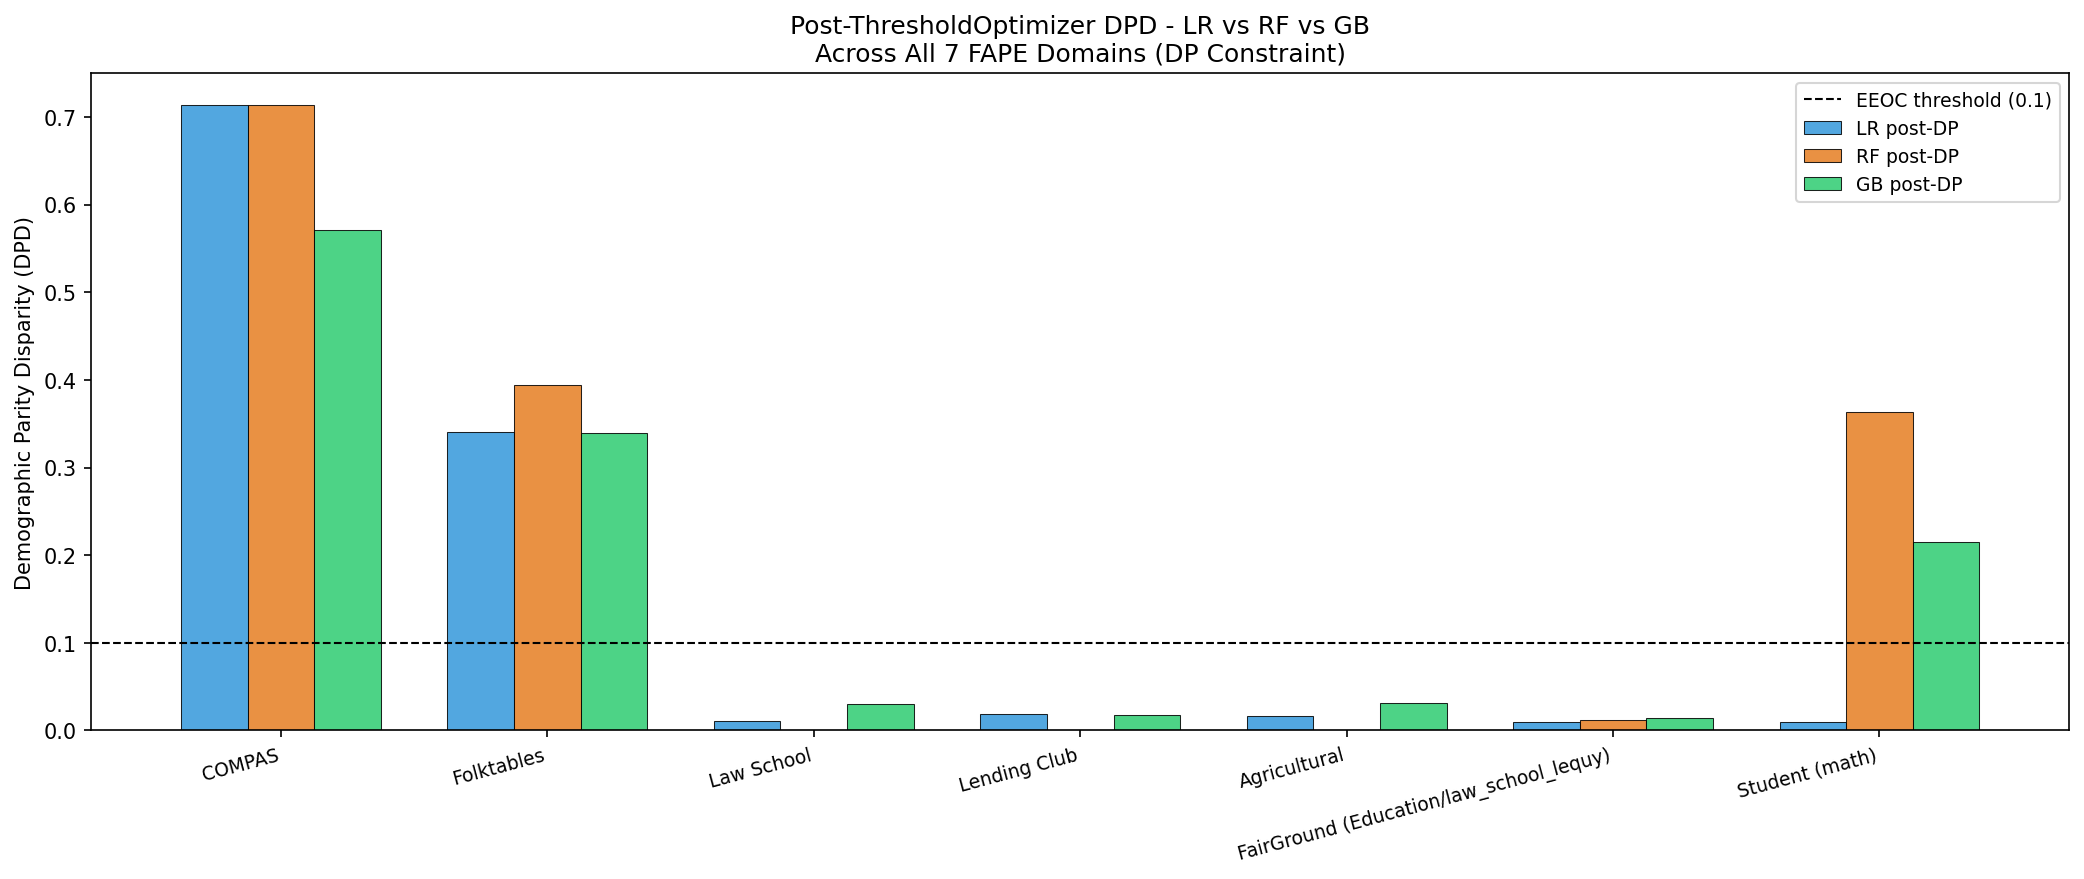

In [4]:
Image('../figures/stage2/aggregation_post_dp_dpd.png')

## 3. Post-EO EOD, LR vs RF vs GB

EOD after EO constraint across all 7 domains. Student shows strongest improvement across all 3 models; Law School shows strong improvement in the 2 models tested (RF not tested in this domain). COMPAS remains challenging, GB EOD=0.659 after constraint.

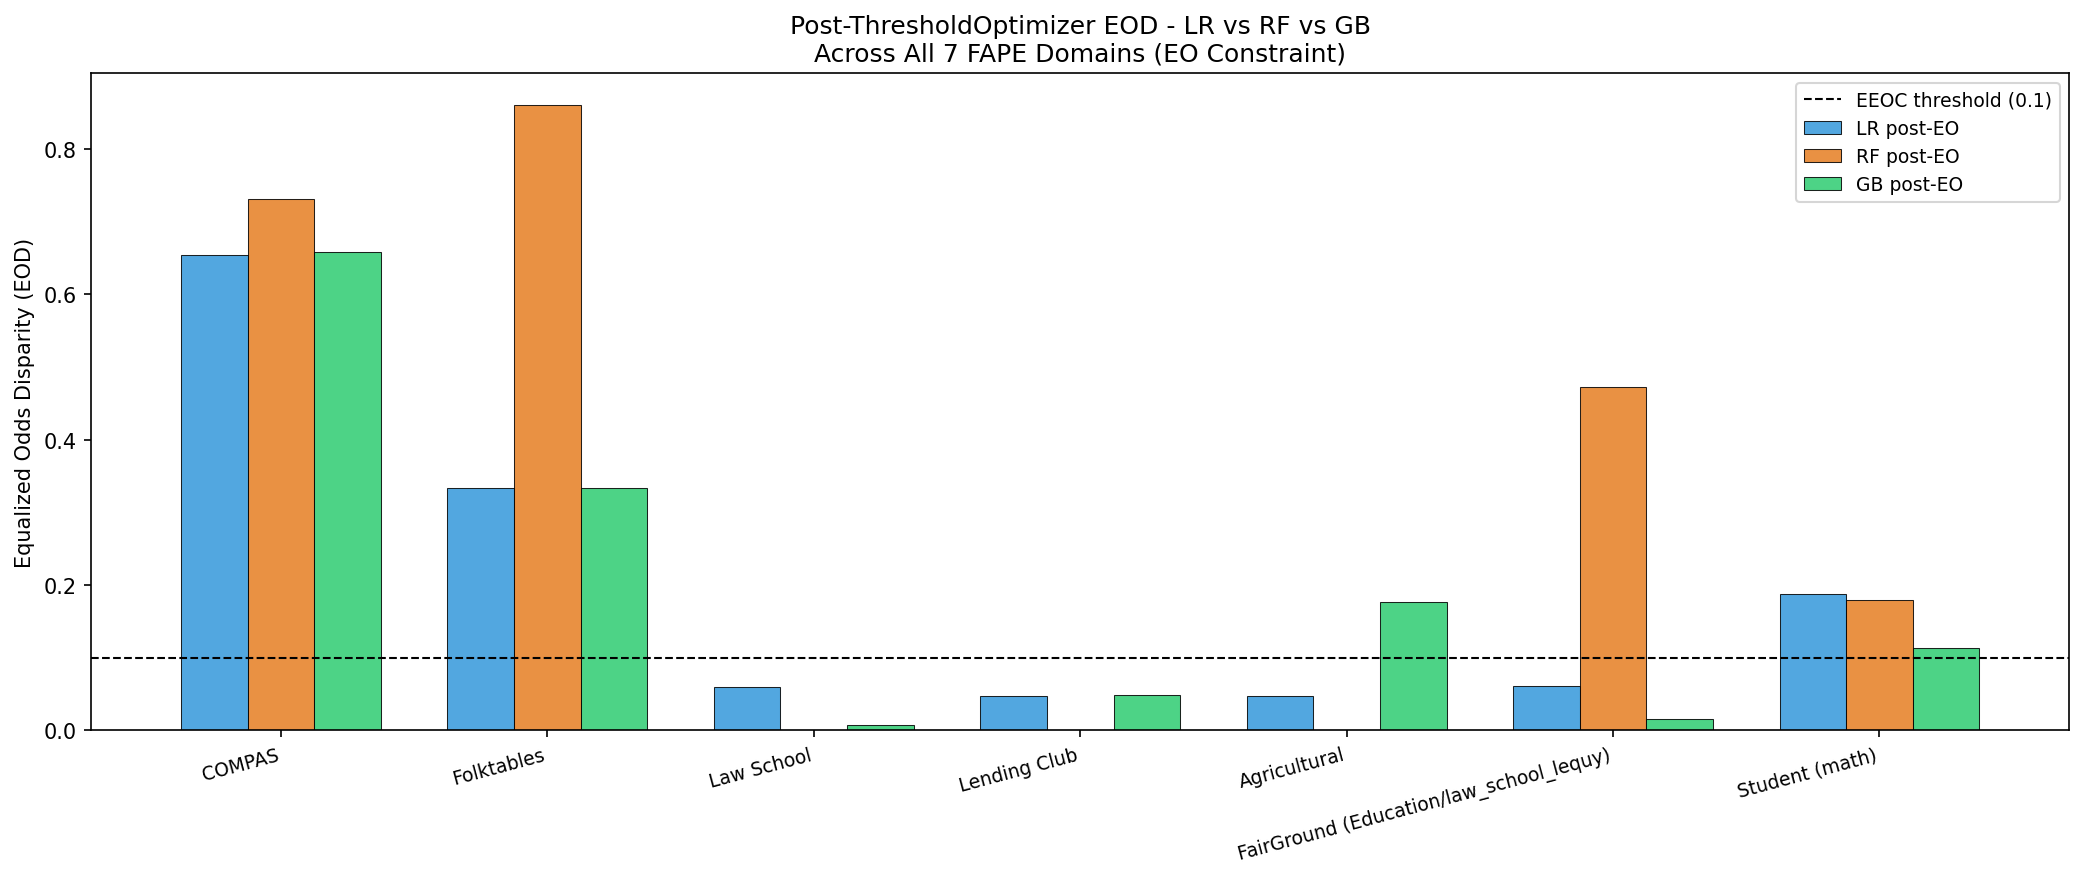

In [5]:
Image('../figures/stage2/aggregation_post_eo_eod.png')

## 4. Post-DP DPD Heatmap, All Models × All Domains

Full DPD matrix after DP constraint. Green = low DPD (fair), red = high DPD (unfair). FairGround and Law School achieve the strongest post-constraint fairness among domains with RF tested and untested respectively.

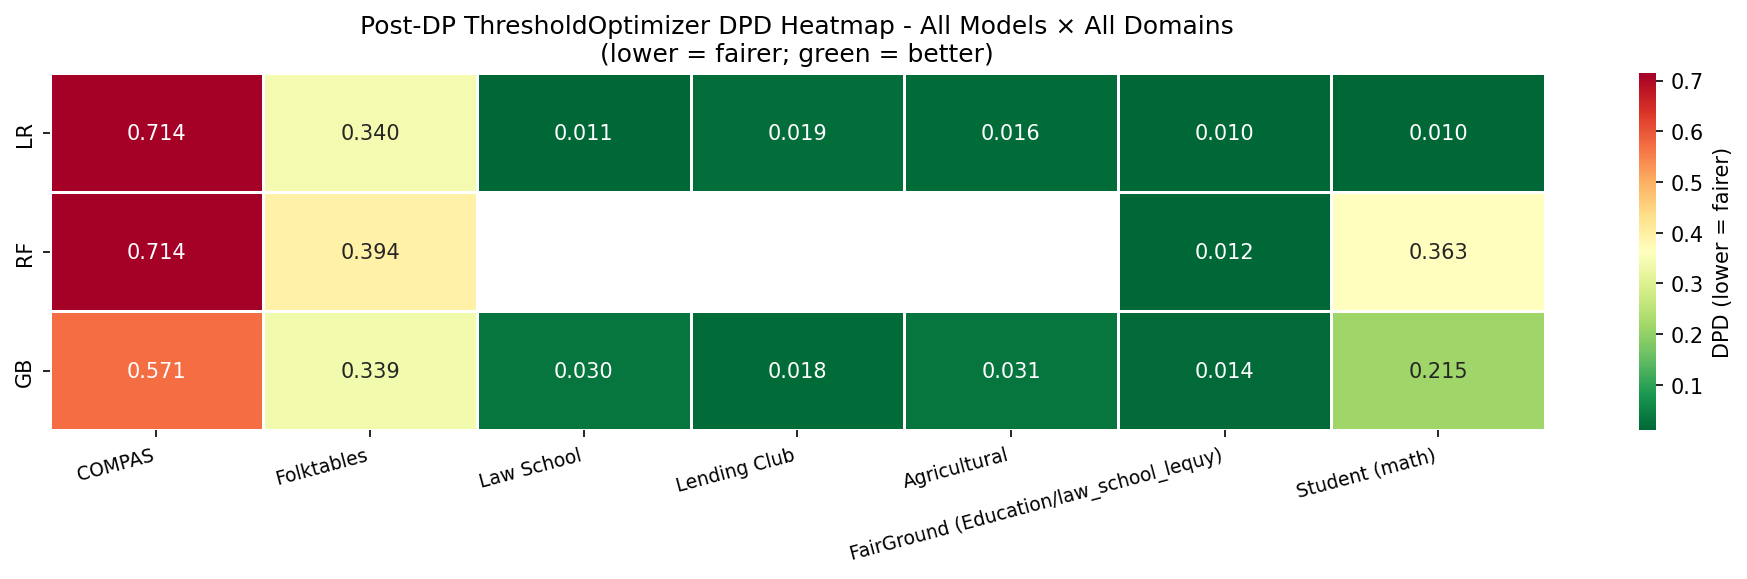

In [6]:
Image('../figures/stage2/aggregation_dpd_heatmap.png')

## 5. Post-EO EOD Heatmap, All Models × All Domains

Full EOD matrix after EO constraint. Law School GB achieves the strongest EOD result (0.528→0.007). COMPAS remains a challenging domain across all models.

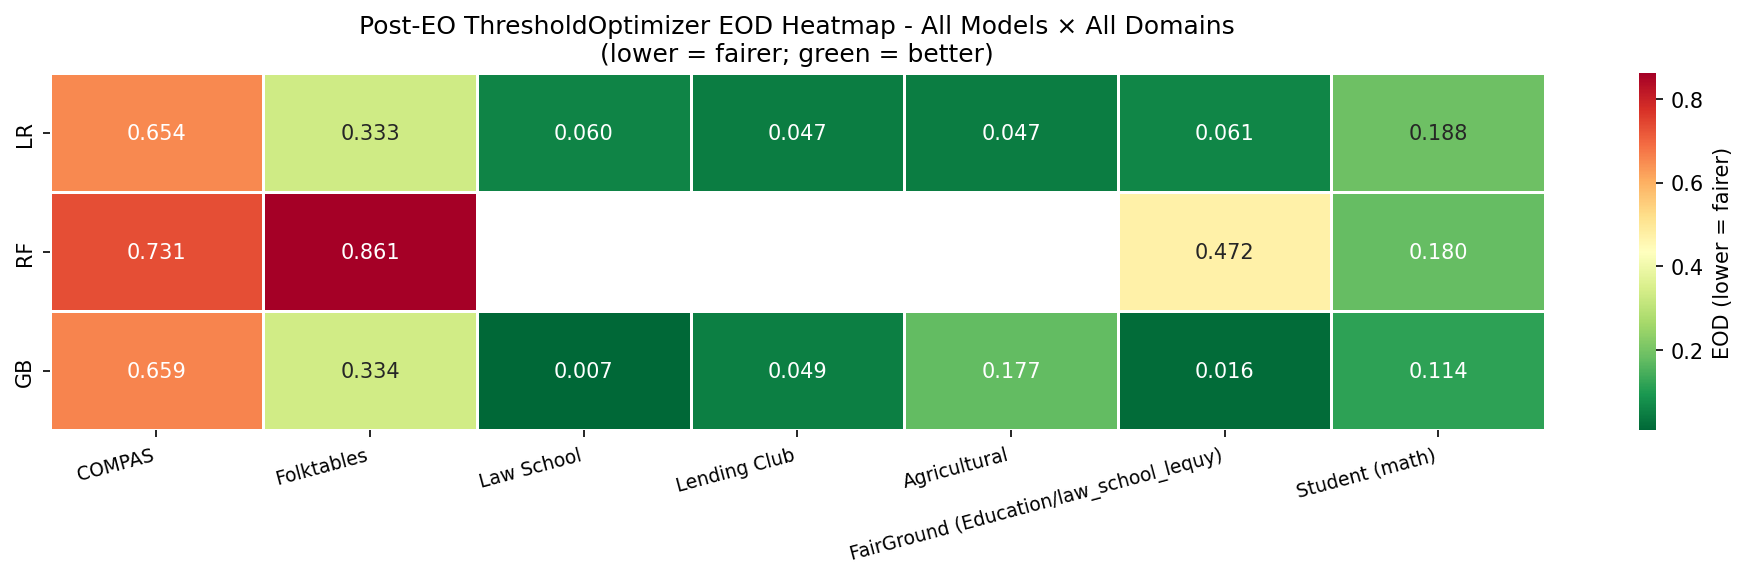

In [7]:
Image('../figures/stage2/aggregation_eod_heatmap.png')

## 6. Accuracy Cost Heatmap, All Models × All Domains

Accuracy drop under DP constraint across all models and domains. FairGround GB highest cost (0.159). Law School LR and GB (RF not tested) show near-zero cost despite large fairness improvement. Lowest-cost model varies by domain, not consistently LR.

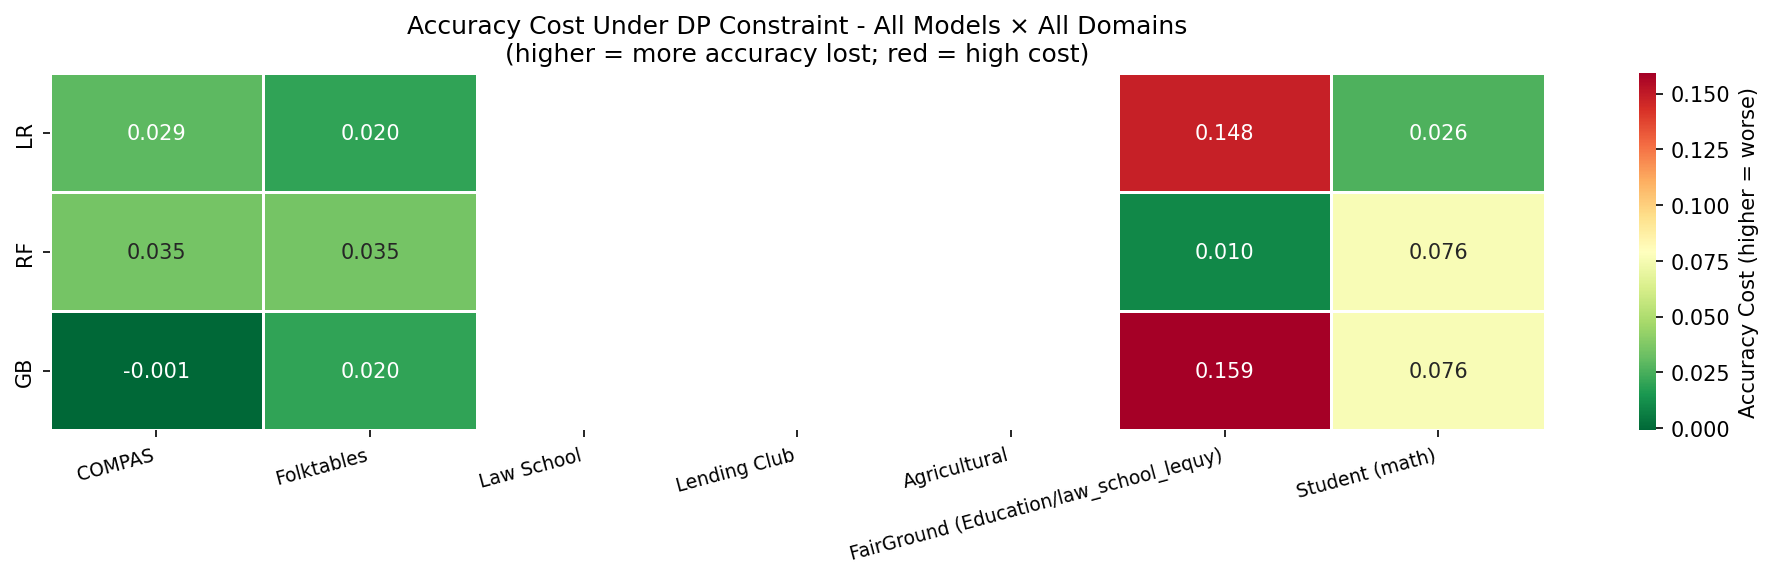

In [8]:
Image('../figures/stage2/aggregation_acc_cost_heatmap.png')

## 7. Key Findings

**Model ranking, baseline accuracy:**
No fixed GB > RF > LR ordering holds across all 7 domains; COMPAS is LR > GB > RF specifically. Gap between GB and its nearest competitor is largest in Agricultural and smallest in Law School.

**Model ranking, fairness improvement:**
- Law School: LR and GB both improve (GB best: DPD 0.351→0.030); RF not tested in this domain
- COMPAS: GB most effective (DPD 0.857→0.571); LR/RF worsen under DP
- Agricultural: GB counterproductive when near-fair baseline; RF not tested
- FairGround: GB strongest improvement (DPD 0.342→0.014) at highest accuracy cost (0.159)

**Model stability:**
Accuracy cost is domain-dependent: GB has the lowest cost in COMPAS (0.001) and Folktables (tied with LR), while LR has the lowest cost in FairGround and Student. No single model is uniformly cheapest across constraints.

**FAPE contribution:**
No single model dominates across all domains. Domain-specific model selection is required for production fairness auditing.